In [ ]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import snowflake.connector


conn = snowflake.connector.connect(
    user="",
    password="",
    account="",
    warehouse="TAXI_WH",
    database="TAXI_DB",
    schema="RAW"
    )

df   = pd.read_sql('''
    SELECT TRIP_SECONDS, TRIP_MILES, FARE, TIPS, EXTRAS,
           PICKUP_COMMUNITY_AREA, DROPOFF_COMMUNITY_AREA,
           HOUR(TRIP_START_TIMESTAMP)      AS PICKUP_HOUR,
           DAYOFWEEK(TRIP_START_TIMESTAMP)  AS PICKUP_DOW
    FROM TAXI_DB.RAW.CHICAGO_TRIPS
    WHERE FARE > 0 AND TRIP_SECONDS > 0
    LIMIT 100000
''', conn)
df.columns = df.columns.str.lower()
conn.close()


df['tipped']      = (df['tips'] > 0).astype(int)
df['fare_per_mile'] = df['fare'] / df['trip_miles'].replace(0, float('nan'))


print(f'Overall tip rate: {df["tipped"].mean():.2%}')





C:\Users\brand\AppData\Local\Temp\ipykernel_28608\4125924896.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df   = pd.read_sql('''


Overall tip rate: 42.06%


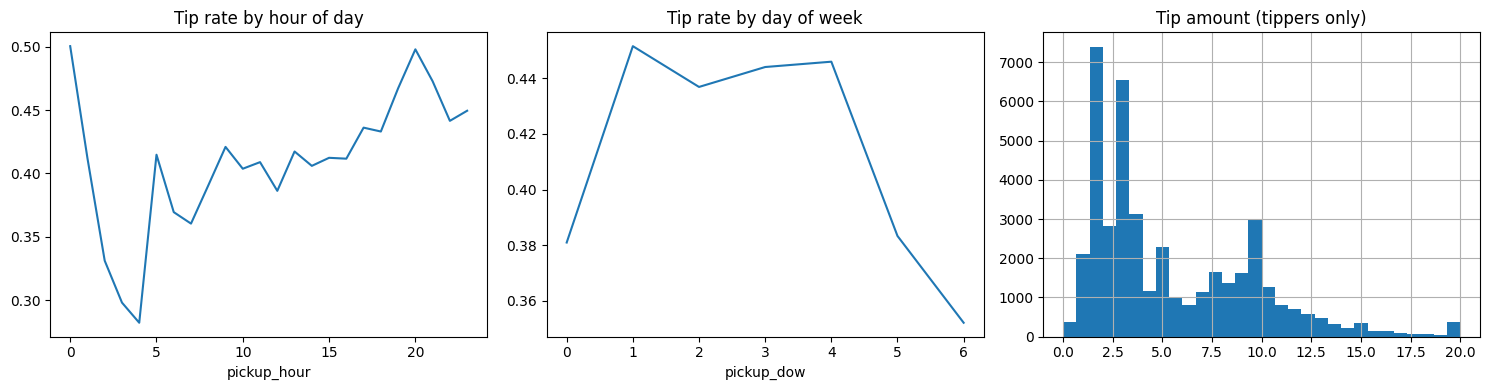

In [13]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
df.groupby('pickup_hour')['tipped'].mean().plot(ax=axes[0], title='Tip rate by hour of day')
df.groupby('pickup_dow')['tipped'].mean().plot(ax=axes[1],  title='Tip rate by day of week')
df[df['tipped']==1]['tips'].clip(0,20).hist(ax=axes[2], bins=30)#, title='Tip amount (tippers only)')
plt.title('Tip amount (tippers only)')
plt.tight_layout(); 
plt.savefig('eda_tip_patterns.png',dpi=120); 
plt.show()